# SVR with Bayesian Optimization 
## Support Vector Regression Model Training

 Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from skopt import BayesSearchCV
from skopt.space import Real

sns.set_style("whitegrid")

 Load Data

In [6]:
file_path = r'../data/LMA_Dataset.csv'
df = pd.read_csv(file_path, skiprows=4)
df.columns = df.columns.str.replace('% ', '')

input_features = ['Lp (m)', 'Wp (m)', 'Wf (m)', 'hs (m)', 'er', 'Ls (m)', 'Ws (m)', 'tp (m)', 'tg (m)', 'Lf (m)', 'freq (GHz)']
output_targets = ['S11(geometry) (1)', 'Voltage standing wave ratio(geometry) (1)', 'real part of zero impedence(geometry) (Ω)', 'imaginarygeometry) (Ω)', 'Maximum gain, dB(radiation) (1)', 'Maximum directivity, dB(radiation) (1)', 'Total radiated power, dB(radiation) (W)', '(radiation) (1)']
output_names = ['S11', 'VSWR', 'Re(Z)', 'Im(Z)', 'Gain', 'Directivity', 'TRP', 'Efficiency']

X = df[input_features].values
Y = df[output_targets].values
print(f"Loaded {X.shape[0]} samples")

Loaded 2700 samples


 Preprocess

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.20, random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)

print(f"Training: {X_train.shape[0]}, Testing: {X_test.shape[0]}")

Training: 2160, Testing: 540


 Train Models

In [8]:
search_space = {
    'C': Real(0.1, 1000, prior='log-uniform'),
    'epsilon': Real(0.001, 1.0, prior='log-uniform'),
    'gamma': Real(1e-6, 1e-1, prior='log-uniform'),
}

all_models = {}
all_results = {}

print("Training 8 SVR models...\n")

for i, output_name in enumerate(output_names):
    print(f"Training {i+1}/8: {output_name}")
    
    Y_train_current = Y_train_scaled[:, i]
    Y_test_current = Y_test_scaled[:, i]
    
    svr = SVR(kernel='rbf')
    bayes_opt = BayesSearchCV(estimator=svr, search_spaces=search_space, n_iter=32, cv=5, n_jobs=-1, verbose=0, random_state=42, scoring='neg_mean_squared_error')
    
    start_time = time.time()
    bayes_opt.fit(X_train_scaled, Y_train_current)
    train_time = (time.time() - start_time) / 60
    
    best_model = bayes_opt.best_estimator_
    Y_pred = best_model.predict(X_test_scaled)
    
    r2 = r2_score(Y_test_current, Y_pred)
    
    mean_val = scaler_Y.mean_[i]
    std_val = scaler_Y.scale_[i]
    Y_pred_orig = (Y_pred * std_val) + mean_val
    Y_test_orig = (Y_test_current * std_val) + mean_val
    
    rmse_orig = np.sqrt(mean_squared_error(Y_test_orig, Y_pred_orig))
    mae_orig = mean_absolute_error(Y_test_orig, Y_pred_orig)
    
    all_models[output_name] = best_model
    all_results[output_name] = {
        'best_params': bayes_opt.best_params_,
        'test_r2': r2,
        'test_rmse_orig': rmse_orig,
        'test_mae_orig': mae_orig,
        'train_time': train_time
    }
    
    print(f"  R² = {r2:.4f}, Time = {train_time:.2f} min\n")

print("Training complete")

Training 8 SVR models...

Training 1/8: S11
  R² = 0.8953, Time = 6.77 min

Training 2/8: VSWR
  R² = 0.9724, Time = 4.15 min

Training 3/8: Re(Z)
  R² = 0.9353, Time = 3.77 min

Training 4/8: Im(Z)
  R² = 0.9572, Time = 1.23 min

Training 5/8: Gain
  R² = 0.9815, Time = 2.85 min

Training 6/8: Directivity


C:\Users\Abi\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.001, 0.1] before, using random point [4.277074159173846, 0.3324572866412493, 0.0062860541435735915]
  warnings.warn(
C:\Users\Abi\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.001, 0.1] before, using random point [3.5885534700055004, 0.0024404134790602214, 0.00018766517544762312]
  warnings.warn(
C:\Users\Abi\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.001, 0.1] before, using random point [401.1183343281504, 0.012637543934794446, 0.0023804681419732233]
  warnings.warn(
C:\Users\Abi\AppData\Roaming\Python\Python313\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [1000.0, 0.00

  R² = 0.8270, Time = 1.63 min

Training 7/8: TRP
  R² = 0.9520, Time = 0.98 min

Training 8/8: Efficiency
  R² = 0.9564, Time = 3.84 min

Training complete


 Performance Summary

In [9]:
results_df = pd.DataFrame([{
    'Output': name,
    'R²': all_results[name]['test_r2'],
    'RMSE': all_results[name]['test_rmse_orig'],
    'MAE': all_results[name]['test_mae_orig']
} for name in output_names])

print("="*70)
print("SVR MODEL PERFORMANCE")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)
print(f"\nAverage R²: {results_df['R²'].mean():.4f}")

SVR MODEL PERFORMANCE
     Output       R²     RMSE      MAE
        S11 0.895258 0.764133 0.278445
       VSWR 0.972352 0.058716 0.027169
      Re(Z) 0.935317 3.516350 1.559311
      Im(Z) 0.957247 3.079647 1.940366
       Gain 0.981500 0.368827 0.241453
Directivity 0.826985 0.299122 0.214653
        TRP 0.952023 0.620163 0.469901
 Efficiency 0.956431 0.032234 0.013628

Average R²: 0.9346


 Predict Test Set

In [10]:
Y_test_pred = np.zeros((len(X_test), 8))

for i, output_name in enumerate(output_names):
    model = all_models[output_name]
    Y_pred_scaled = model.predict(X_test_scaled)
    mean_val = scaler_Y.mean_[i]
    std_val = scaler_Y.scale_[i]
    Y_test_pred[:, i] = (Y_pred_scaled * std_val) + mean_val

print("Test predictions ready")

Test predictions ready


 Find Best Designs

In [11]:
param_descriptions = [('Lp (m)', 'Patch Length'), ('Wp (m)', 'Patch Width'), ('Wf (m)', 'Feed Width'), ('hs (m)', 'Substrate Height'), ('er', 'Relative Permittivity'), ('Ls (m)', 'Substrate Length'), ('Ws (m)', 'Substrate Width'), ('tp (m)', 'Patch Thickness'), ('tg (m)', 'Ground Thickness'), ('Lf (m)', 'Feed Length'), ('freq (GHz)', 'Operating Frequency')]

output_descriptions = [('S11 (dB)', 'Return Loss'), ('VSWR', 'Voltage Standing Wave Ratio'), ('Re(Z) (Ω)', 'Real Impedance'), ('Im(Z) (Ω)', 'Imaginary Impedance'), ('Gain (dB)', 'Maximum Gain'), ('Directivity (dB)', 'Maximum Directivity'), ('TRP (dBW)', 'Total Radiated Power'), ('Efficiency', 'Radiation Efficiency')]

# Best S11
best_s11_idx = np.argmin(Y_test_pred[:, 0])
best_s11_design = X_test[best_s11_idx]
best_s11_performance = Y_test_pred[best_s11_idx]

print("="*70)
print("BEST S11 DESIGN")
print("="*70)
print("\nGEOMETRY:")
for (unit, desc), val in zip(param_descriptions, best_s11_design):
    print(f"  {desc:25s} ({unit:12s}): {val:.6f}")
print("\nPERFORMANCE:")
for (unit, desc), val in zip(output_descriptions, best_s11_performance):
    if 'Efficiency' in desc:
        print(f"  {desc:25s} ({unit:12s}): {val:.4f} ({val*100:.2f}%)")
    else:
        print(f"  {desc:25s} ({unit:12s}): {val:.4f}")
print("="*70)

BEST S11 DESIGN

GEOMETRY:
  Patch Length              (Lp (m)      ): 0.003900
  Patch Width               (Wp (m)      ): 0.005700
  Feed Width                (Wf (m)      ): 0.000200
  Substrate Height          (hs (m)      ): 0.001800
  Relative Permittivity     (er          ): 3.000000
  Substrate Length          (Ls (m)      ): 0.029500
  Substrate Width           (Ws (m)      ): 0.007000
  Patch Thickness           (tp (m)      ): 0.000035
  Ground Thickness          (tg (m)      ): 0.000500
  Feed Length               (Lf (m)      ): 0.001000
  Operating Frequency       (freq (GHz)  ): 19.000000

PERFORMANCE:
  Return Loss               (S11 (dB)    ): -22.1426
  Voltage Standing Wave Ratio (VSWR        ): 1.0128
  Real Impedance            (Re(Z) (Ω)   ): 43.1749
  Imaginary Impedance       (Im(Z) (Ω)   ): 11.8105
  Maximum Gain              (Gain (dB)   ): 5.8499
  Maximum Directivity       (Directivity (dB)): 6.6700
  Total Radiated Power      (TRP (dBW)   ): -19.3229
  Radi

In [12]:
# Calculate error metrics as per literature
print("="*80)
print("ERROR METRICS ANALYSIS")
print("="*80)

# Calculate output errors, MSE, and error percentages for each output
error_metrics = []

for i, output_name in enumerate(output_names):
    # Get actual and predicted values
    y_actual = Y_test[:, i]
    y_predicted = Y_test_pred[:, i]
    
    # Output Error: ei = yd - yi
    output_errors = y_actual - y_predicted
    
    # MSE: (1/N) * sum(ei^2)
    mse = np.mean(output_errors**2)
    
    # Error Percentage: |yd - yi| / |yd| * 100
    error_percentages = np.abs((y_actual - y_predicted) / y_actual) * 100
    mean_error_percent = np.mean(error_percentages)
    max_error_percent = np.max(error_percentages)
    
    # RMSE
    rmse = np.sqrt(mse)
    
    # MAE
    mae = np.mean(np.abs(output_errors))
    
    error_metrics.append({
        'Output': output_name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'Mean Error %': mean_error_percent,
        'Max Error %': max_error_percent
    })
    
    print(f"\n{output_name}:")
    print(f"  MSE:                {mse:.6f}")
    print(f"  RMSE:               {rmse:.6f}")
    print(f"  MAE:                {mae:.6f}")
    print(f"  Mean Error %:       {mean_error_percent:.4f}%")
    print(f"  Max Error %:        {max_error_percent:.4f}%")
    print(f"  Error Range:        [{output_errors.min():.4f}, {output_errors.max():.4f}]")

print("\n" + "="*80)

# Create summary dataframe
error_df = pd.DataFrame(error_metrics)
print("\nERROR METRICS SUMMARY TABLE:")
print(error_df.to_string(index=False))
print("="*80)

ERROR METRICS ANALYSIS

S11:
  MSE:                0.583899
  RMSE:               0.764133
  MAE:                0.278445
  Mean Error %:       2.4437%
  Max Error %:        64.0203%
  Error Range:        [-7.5991, 8.6427]

VSWR:
  MSE:                0.003448
  RMSE:               0.058716
  MAE:                0.027169
  Mean Error %:       1.4980%
  Max Error %:        34.0625%
  Error Range:        [-0.3143, 0.5232]

Re(Z):
  MSE:                12.364720
  RMSE:               3.516350
  MAE:                1.559311
  Mean Error %:       1.7546%
  Max Error %:        23.3500%
  Error Range:        [-19.1143, 16.1892]

Im(Z):
  MSE:                9.484227
  RMSE:               3.079647
  MAE:                1.940366
  Mean Error %:       44.2580%
  Max Error %:        1723.9677%
  Error Range:        [-15.0580, 10.3088]

Gain:
  MSE:                0.136033
  RMSE:               0.368827
  MAE:                0.241453
  Mean Error %:       46.9818%
  Max Error %:        5853.4919%


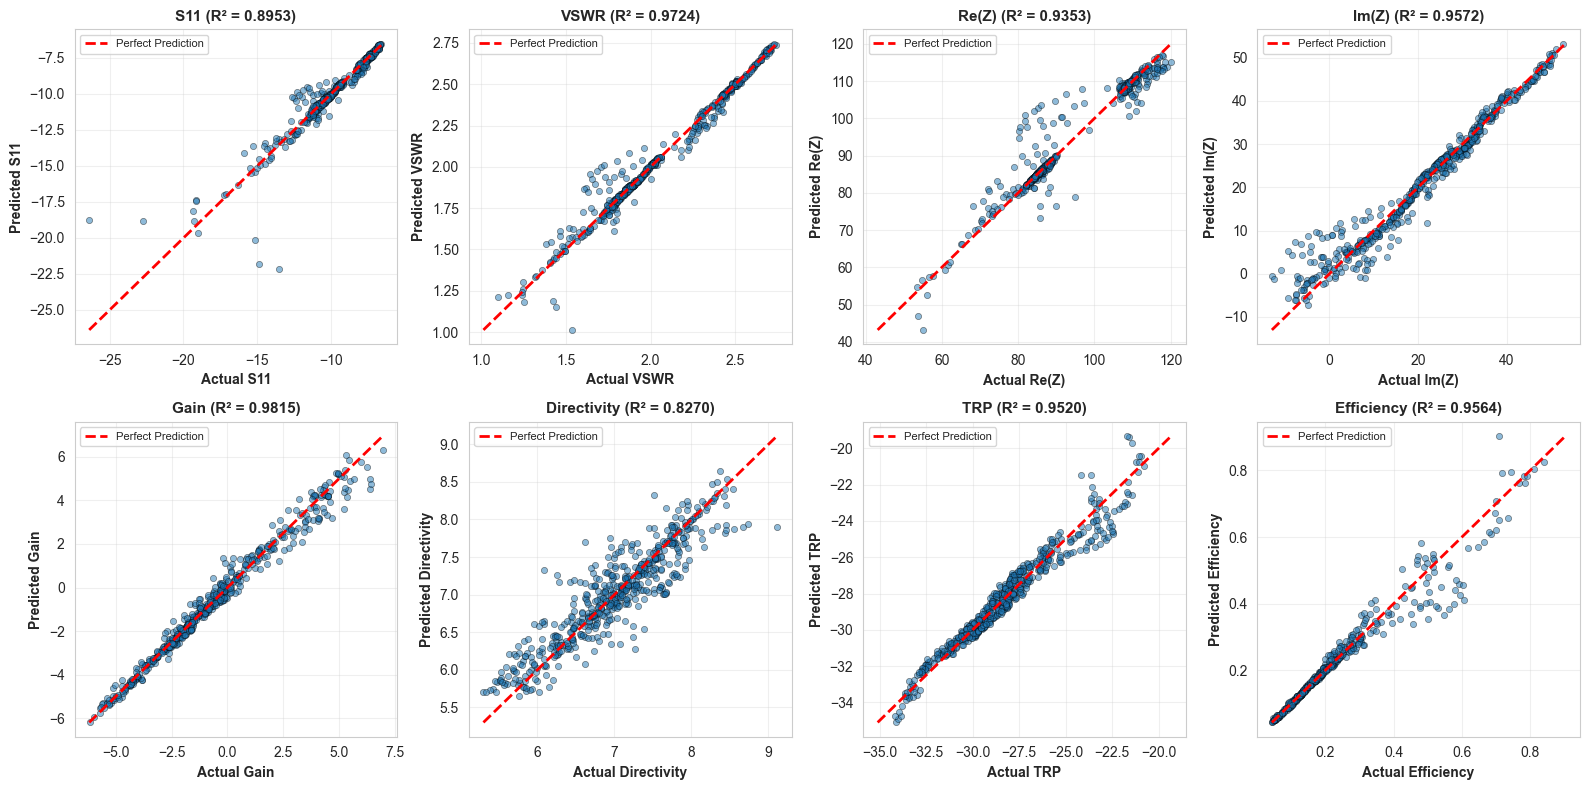

Figure saved: SVR_Actual_vs_Predicted.png


In [13]:
# Create actual vs predicted scatter plots for all outputs
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, output_name in enumerate(output_names):
    ax = axes[i]
    
    y_actual = Y_test[:, i]
    y_predicted = Y_test_pred[:, i]
    
    # Scatter plot
    ax.scatter(y_actual, y_predicted, alpha=0.5, s=20, edgecolor='black', linewidth=0.5)
    
    # Perfect prediction line
    min_val = min(y_actual.min(), y_predicted.min())
    max_val = max(y_actual.max(), y_predicted.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    # Calculate R²
    r2 = all_results[output_name]['test_r2']
    
    ax.set_xlabel(f'Actual {output_name}', fontsize=10, fontweight='bold')
    ax.set_ylabel(f'Predicted {output_name}', fontsize=10, fontweight='bold')
    ax.set_title(f'{output_name} (R² = {r2:.4f})', fontsize=11, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('SVR_Actual_vs_Predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: SVR_Actual_vs_Predicted.png")

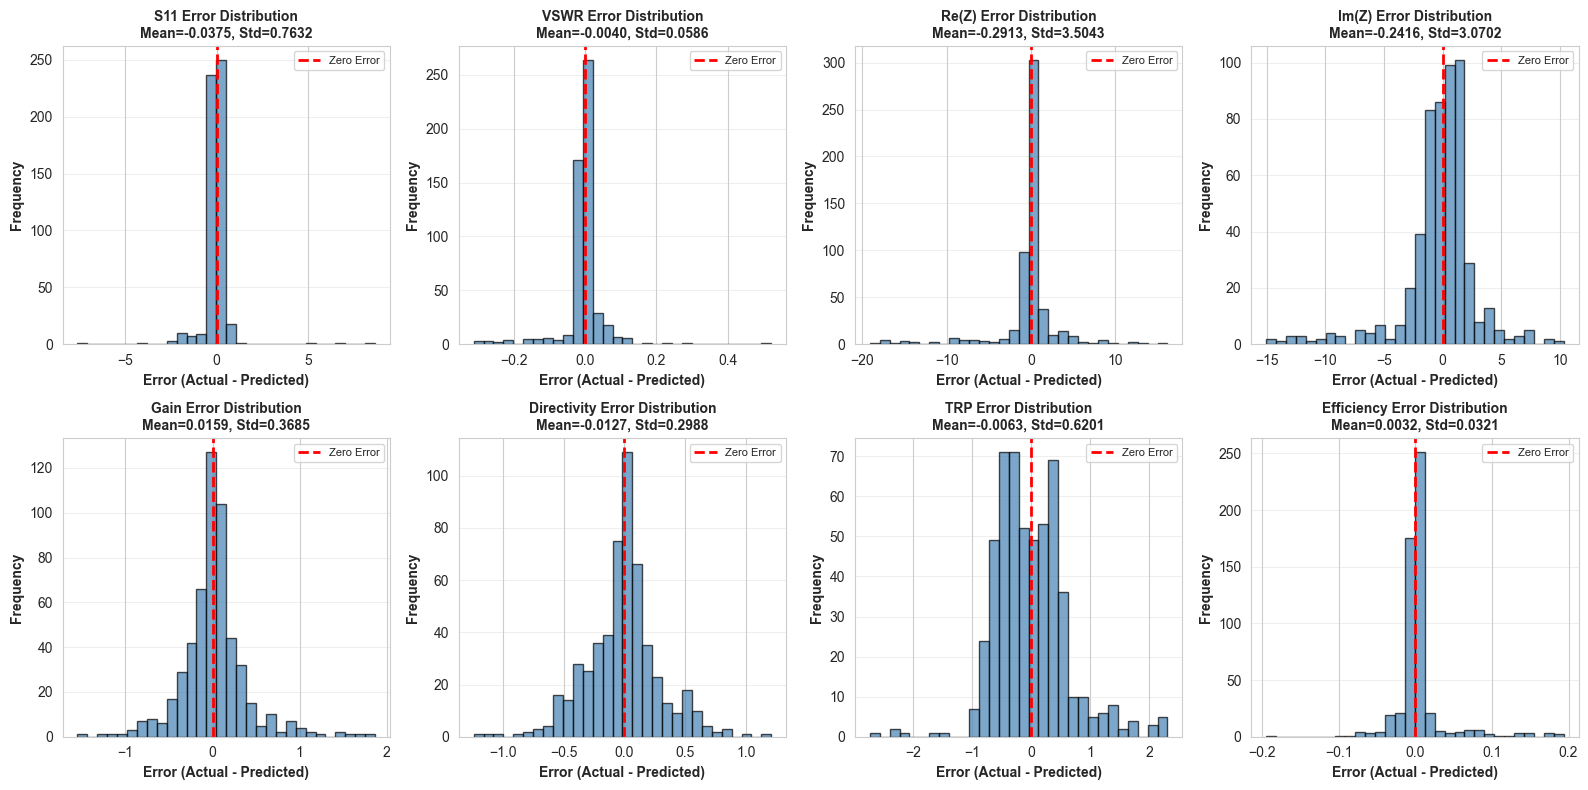

Figure saved: SVR_Error_Distribution.png


In [14]:
# Create error distribution histograms
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, output_name in enumerate(output_names):
    ax = axes[i]
    
    y_actual = Y_test[:, i]
    y_predicted = Y_test_pred[:, i]
    errors = y_actual - y_predicted
    
    # Histogram
    ax.hist(errors, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
    
    # Statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    
    ax.set_xlabel(f'Error (Actual - Predicted)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
    ax.set_title(f'{output_name} Error Distribution\nMean={mean_error:.4f}, Std={std_error:.4f}', 
                fontsize=10, fontweight='bold')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('SVR_Error_Distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: SVR_Error_Distribution.png")

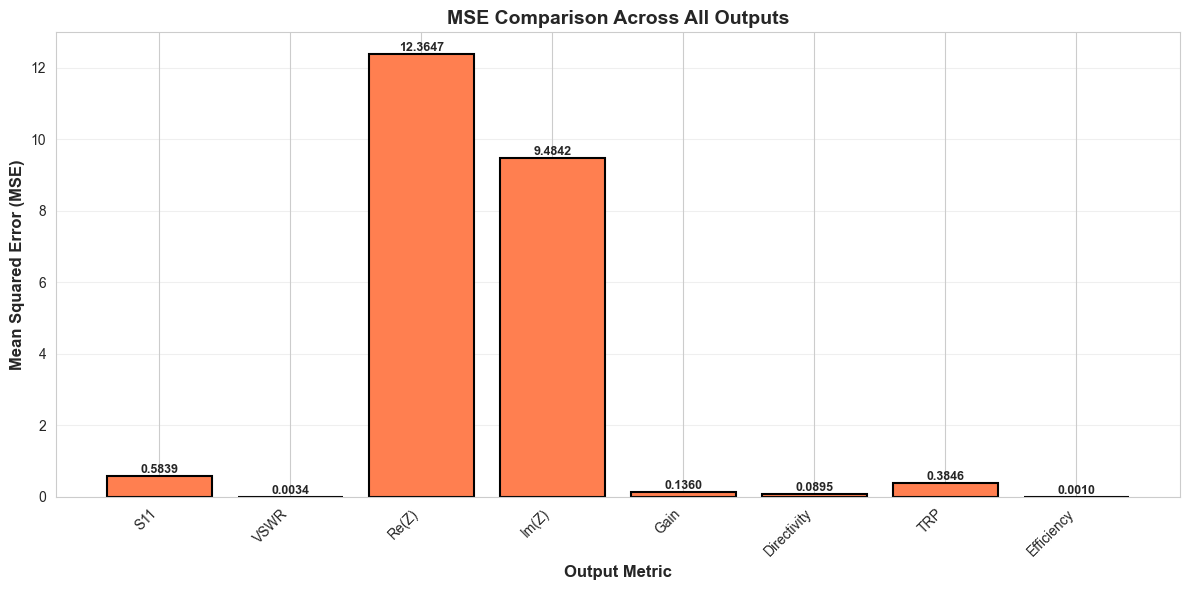

Figure saved: SVR_MSE_Comparison.png


In [15]:
# Create bar chart comparing MSE across outputs
fig, ax = plt.subplots(figsize=(12, 6))

outputs = [metric['Output'] for metric in error_metrics]
mse_values = [metric['MSE'] for metric in error_metrics]

bars = ax.bar(outputs, mse_values, edgecolor='black', linewidth=1.5, color='coral')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Output Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
ax.set_title('MSE Comparison Across All Outputs', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('SVR_MSE_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: SVR_MSE_Comparison.png")

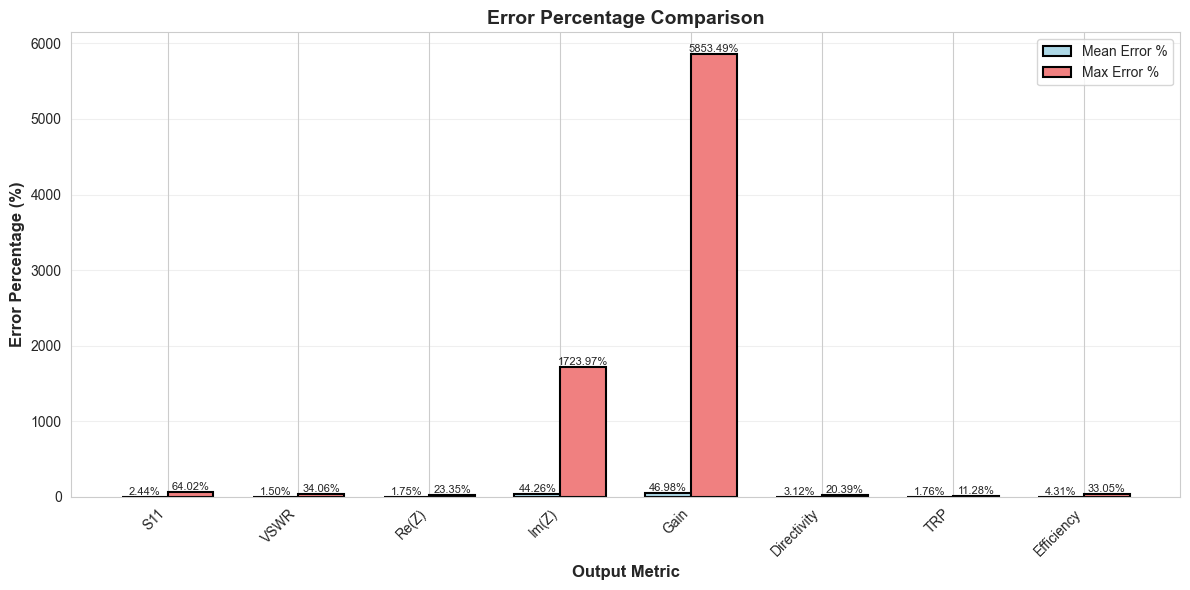

Figure saved: SVR_Error_Percentage.png


In [ ]:
# Create bar chart comparing error percentages
fig, ax = plt.subplots(figsize=(12, 6))

outputs = [metric['Output'] for metric in error_metrics]
mean_error_pct = [metric['Mean Error %'] for metric in error_metrics]
max_error_pct = [metric['Max Error %'] for metric in error_metrics]

x = np.arange(len(outputs))
width = 0.35

bars1 = ax.bar(x - width/2, mean_error_pct, width, label='Mean Error %', 
            edgecolor='black', linewidth=1.5, color='lightblue')
bars2 = ax.bar(x + width/2, max_error_pct, width, label='Max Error %', 
            edgecolor='black', linewidth=1.5, color='lightcoral')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}%',
                ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Output Metric', fontsize=12, fontweight='bold')
ax.set_ylabel('Error Percentage (%)', fontsize=12, fontweight='bold')
ax.set_title('Error Percentage Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(outputs, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('SVR_Error_Percentage.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved: SVR_Error_Percentage.png")